# Laboratorio 8 — MM3014 Teoría de Probabilidades
### Etapa 3: Incorporación del presupuesto y costo
### Etapa 4: Efecto del intercambio de repetidas
#### Andrés Ismalej 24005 y Jennifer Toxcon 21276 
---

## 1. Importación de librerías

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

## 2. Funciones base reutilizables

Se redefinen las funciones del Lab 7

In [3]:
def simular_album(N, S):
    """
    Simula el llenado completo de un álbum de N estampas con sobres de S estampas.
    Retorna (sobres_comprados, repetidas).
    """
    collected = np.zeros(N, dtype=bool)
    universe  = np.arange(N)
    packs     = 0
    repeats   = 0

    while not collected.all():
        pack = np.random.choice(universe, size=S, replace=False)
        packs += 1
        new_in_pack = (~collected[pack]).sum()
        repeats += S - new_in_pack
        collected[pack] = True

    return packs, repeats


def simular_album_presupuesto(N, S, precio_sobre, presupuesto):
    """
    Simula la compra de sobres hasta agotar el presupuesto o completar el álbum.

    Retorna
    -------
    completado   : bool   — True si se completó el álbum
    packs        : int    — sobres comprados
    unique_count : int    — estampas distintas obtenidas
    """
    collected    = np.zeros(N, dtype=bool)
    universe     = np.arange(N)
    gasto        = 0.0
    packs        = 0
    unique_count = 0

    while (gasto + precio_sobre <= presupuesto) and (unique_count < N):
        pack = np.random.choice(universe, size=S, replace=False)
        packs += 1
        gasto += precio_sobre
        new_in_pack = (~collected[pack]).sum()
        collected[pack] = True
        unique_count += new_in_pack

    completado = unique_count == N
    return completado, packs, unique_count


def simular_album_intercambio(N, S, K):
    """
    Simula el llenado del álbum con mecanismo de intercambio:
    cada K repetidas se canjean por 1 estampa nueva a elección.

    Retorna
    -------
    packs   : int — sobres comprados
    repeats : int — repetidas acumuladas (antes de canje)
    """
    collected  = set()
    faltantes  = set(range(N))
    packs      = 0
    repeats    = 0
    rep_buffer = 0  # repetidas acumuladas pendientes de canje

    while len(collected) < N:
        pack = np.random.choice(N, size=S, replace=False)
        packs += 1

        for sticker in pack:
            if sticker in collected:
                repeats    += 1
                rep_buffer += 1
            else:
                collected.add(sticker)
                faltantes.discard(sticker)

        # Realizar canjes disponibles
        while rep_buffer >= K and faltantes:
            nueva = np.random.choice(list(faltantes))
            collected.add(nueva)
            faltantes.discard(nueva)
            rep_buffer -= K

    return packs, repeats

---
# ETAPA 3: Incorporación del presupuesto y costo

## 3. Parámetros — Etapa 3

In [4]:
N            = 100      # estampas diferentes
S            = 7        # estampas por sobre
R            = 10_000   # simulaciones
SEED         = 2026
PRECIO_SOBRE = 9.50     # Q
PRESUPUESTO  = 1000.0   # Q
PRECIO_CAJA  = 975.0    # Q
SOBRES_CAJA  = 104

np.random.seed(SEED)

## 4. Simulación con presupuesto — sobres sueltos

In [5]:
completados_sueltos = np.empty(R, dtype=bool)
packs_sueltos       = np.empty(R, dtype=int)
unique_sueltos      = np.empty(R, dtype=int)

for r in range(R):
    c, p, u = simular_album_presupuesto(N, S, PRECIO_SOBRE, PRESUPUESTO)
    completados_sueltos[r] = c
    packs_sueltos[r]       = p
    unique_sueltos[r]      = u

prob_exito_sueltos   = completados_sueltos.mean()
mean_packs_sueltos   = packs_sueltos.mean()
# Estampas distintas solo en casos NO exitosos
mask_no_exitosos     = ~completados_sueltos
mean_unique_fracaso  = unique_sueltos[mask_no_exitosos].mean() if mask_no_exitosos.any() else np.nan

print("=== Etapa 3 — Sobres sueltos (Q1000) ===")
print(f"P(completar álbum)              : {prob_exito_sueltos:.4f}  ({prob_exito_sueltos*100:.2f}%)")
print(f"Media de sobres comprados       : {mean_packs_sueltos:.4f}")
print(f"Media de estampas (no exitosos) : {mean_unique_fracaso:.4f}")

=== Etapa 3 — Sobres sueltos (Q1000) ===
P(completar álbum)              : 0.9488  (94.88%)
Media de sobres comprados       : 71.6088
Media de estampas (no exitosos) : 98.9609


## 5. Simulación con caja (104 sobres)

In [6]:
# Se compran exactamente 104 sobres (precio fijo Q975)
# sin restricción adicional de presupuesto durante la compra
completados_caja = np.empty(R, dtype=bool)

for r in range(R):
    collected    = np.zeros(N, dtype=bool)
    universe     = np.arange(N)
    for _ in range(SOBRES_CAJA):
        pack = np.random.choice(universe, size=S, replace=False)
        collected[pack] = True
    completados_caja[r] = collected.all()

prob_exito_caja = completados_caja.mean()

print("=== Etapa 3 — Caja de 104 sobres (Q975) ===")
print(f"P(completar álbum)  : {prob_exito_caja:.4f}  ({prob_exito_caja*100:.2f}%)")

=== Etapa 3 — Caja de 104 sobres (Q975) ===
P(completar álbum)  : 0.9500  (95.00%)


## 6. Visualización — Diagrama de barras (completó vs no completó)

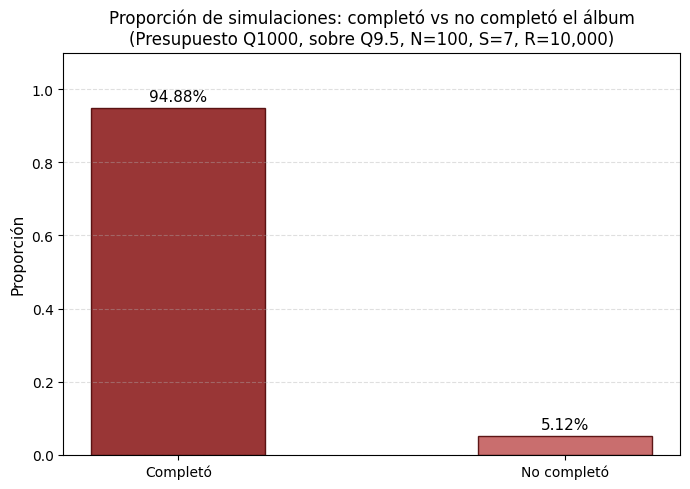

Figura guardada como 'barras_etapa3.png'


In [7]:
COLOR_VINO       = '#8B1A1A'
COLOR_VINO_CLARO = '#C25A5A'

categorias  = ['Completó', 'No completó']
valores     = [prob_exito_sueltos, 1 - prob_exito_sueltos]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    categorias, valores,
    color=[COLOR_VINO, COLOR_VINO_CLARO],
    edgecolor='#4a0000',
    width=0.45,
    alpha=0.88
)

for bar, val in zip(bars, valores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.01,
        f'{val*100:.2f}%',
        ha='center', va='bottom', fontsize=11
    )

ax.set_title('Proporción de simulaciones: completó vs no completó el álbum\n'
             f'(Presupuesto Q{PRESUPUESTO:.0f}, sobre Q{PRECIO_SOBRE}, N={N}, S={S}, R={R:,})',
             fontsize=12)
ax.set_ylabel('Proporción', fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('barras_etapa3.png', dpi=150)
plt.show()
print("Figura guardada como 'barras_etapa3.png'")

---
## 7. Preguntas de análisis — Etapa 3

### Pregunta 1 — Máximo de sobres con Q1000 y comparación con mínimo teórico

In [8]:
max_sobres_presupuesto = int(PRESUPUESTO // PRECIO_SOBRE)
min_teorico            = math.ceil(N / S)

print(f"Máximo de sobres con Q{PRESUPUESTO:.0f}  : {max_sobres_presupuesto} sobres")
print(f"  (floor({PRESUPUESTO} / {PRECIO_SOBRE}) = {max_sobres_presupuesto})")
print()
print(f"Mínimo teórico sin repetidas  : ceil({N}/{S}) = {min_teorico} sobres")
print()
if max_sobres_presupuesto >= min_teorico:
    print(f"Con Q{PRESUPUESTO:.0f} se pueden comprar {max_sobres_presupuesto} sobres, "
          f"que supera el mínimo teórico de {min_teorico}.")
    print("En teoría (sin repetidas) el presupuesto sería suficiente.")
    print("Sin embargo, en la práctica las repetidas reducen la probabilidad de éxito.")
else:
    print(f"El presupuesto NO alcanza ni para el mínimo teórico.")

Máximo de sobres con Q1000  : 105 sobres
  (floor(1000.0 / 9.5) = 105)

Mínimo teórico sin repetidas  : ceil(100/7) = 15 sobres

Con Q1000 se pueden comprar 105 sobres, que supera el mínimo teórico de 15.
En teoría (sin repetidas) el presupuesto sería suficiente.
Sin embargo, en la práctica las repetidas reducen la probabilidad de éxito.


### Pregunta 2 — Comparación: caja de 104 sobres vs sobres sueltos

In [9]:
diferencia = prob_exito_caja - prob_exito_sueltos
costo_sueltos_equivalente = SOBRES_CAJA * PRECIO_SOBRE

print("=== Comparación: caja vs sobres sueltos ===")
print(f"P(éxito) — sobres sueltos (Q{PRESUPUESTO:.0f})  : {prob_exito_sueltos:.4f} ({prob_exito_sueltos*100:.2f}%)")
print(f"P(éxito) — caja 104 sobres (Q{PRECIO_CAJA:.0f}) : {prob_exito_caja:.4f} ({prob_exito_caja*100:.2f}%)")
print()
print(f"Diferencia en probabilidad     : {diferencia:+.4f} ({diferencia*100:+.2f}pp)")
print(f"Costo equivalente 104 sueltos  : Q{costo_sueltos_equivalente:.2f}")
print(f"Costo de la caja               : Q{PRECIO_CAJA:.2f}")
print(f"Ahorro en costo con la caja    : Q{costo_sueltos_equivalente - PRECIO_CAJA:.2f}")
print()
if diferencia > 0:
    print("La caja ofrece mayor probabilidad de éxito Y es más barata que comprar")
    print("104 sobres sueltos. Conviene la caja.")
else:
    print("Los sobres sueltos ofrecen mayor o igual probabilidad de éxito.")

=== Comparación: caja vs sobres sueltos ===
P(éxito) — sobres sueltos (Q1000)  : 0.9488 (94.88%)
P(éxito) — caja 104 sobres (Q975) : 0.9500 (95.00%)

Diferencia en probabilidad     : +0.0012 (+0.12pp)
Costo equivalente 104 sueltos  : Q988.00
Costo de la caja               : Q975.00
Ahorro en costo con la caja    : Q13.00

La caja ofrece mayor probabilidad de éxito Y es más barata que comprar
104 sobres sueltos. Conviene la caja.


### Pregunta 3 — Estrategia mixta: caja + sobres sueltos

In [10]:
presupuesto_restante = PRESUPUESTO - PRECIO_CAJA
sobres_extra         = int(presupuesto_restante // PRECIO_SOBRE)
costo_mixto          = PRECIO_CAJA + sobres_extra * PRECIO_SOBRE
cambio_no_gastado    = PRESUPUESTO - costo_mixto

print("=== Estrategia mixta: 1 caja + sobres sueltos ===")
print(f"Presupuesto total              : Q{PRESUPUESTO:.2f}")
print(f"Costo caja (104 sobres)        : Q{PRECIO_CAJA:.2f}")
print(f"Presupuesto restante           : Q{presupuesto_restante:.2f}")
print(f"Sobres sueltos adicionales     : {sobres_extra} sobres")
print(f"Costo total estrategia mixta   : Q{costo_mixto:.2f}")
print(f"Presupuesto no gastado         : Q{cambio_no_gastado:.2f}")
print()

# Simular la estrategia mixta
total_sobres_mixto   = SOBRES_CAJA + sobres_extra
completados_mixto    = np.empty(R, dtype=bool)

for r in range(R):
    collected = np.zeros(N, dtype=bool)
    universe  = np.arange(N)
    for _ in range(total_sobres_mixto):
        pack = np.random.choice(universe, size=S, replace=False)
        collected[pack] = True
    completados_mixto[r] = collected.all()

prob_exito_mixto = completados_mixto.mean()

print(f"Total sobres en estrategia mixta : {total_sobres_mixto} sobres")
print(f"P(éxito) — estrategia mixta      : {prob_exito_mixto:.4f} ({prob_exito_mixto*100:.2f}%)")
print()
print("=== Resumen comparativo ===")
print(f"{'Estrategia':<30} {'Sobres':>8} {'Costo':>10} {'P(éxito)':>10}")
print("-" * 62)
print(f"{'Sueltos (Q1000)':<30} {max_sobres_presupuesto:>8} {'Q1000.00':>10} {prob_exito_sueltos:>10.4f}")
print(f"{'Caja (104 sobres)':<30} {SOBRES_CAJA:>8} {'Q975.00':>10} {prob_exito_caja:>10.4f}")
print(f"{'Mixta (caja + sueltos)':<30} {total_sobres_mixto:>8} {f'Q{costo_mixto:.2f}':>10} {prob_exito_mixto:>10.4f}")

=== Estrategia mixta: 1 caja + sobres sueltos ===
Presupuesto total              : Q1000.00
Costo caja (104 sobres)        : Q975.00
Presupuesto restante           : Q25.00
Sobres sueltos adicionales     : 2 sobres
Costo total estrategia mixta   : Q994.00
Presupuesto no gastado         : Q6.00

Total sobres en estrategia mixta : 106 sobres
P(éxito) — estrategia mixta      : 0.9565 (95.65%)

=== Resumen comparativo ===
Estrategia                       Sobres      Costo   P(éxito)
--------------------------------------------------------------
Sueltos (Q1000)                     105   Q1000.00     0.9488
Caja (104 sobres)                   104    Q975.00     0.9500
Mixta (caja + sueltos)              106    Q994.00     0.9565


---
# ETAPA 4: Efecto del intercambio de repetidas

## 8. Parámetros — Etapa 4

In [11]:
N4       = 100
S4       = 7
R4       = 10_000
SEED4    = 2026
K_VALS   = [1, 2, 5, 10]
M_VALS   = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]

np.random.seed(SEED4)

## 9. Parte A — Simulación hasta completar el álbum para distintos K

In [28]:
# Caso base sin intercambio (K=inf)
packs_base = np.empty(R4, dtype=int)
for r in range(R4):
    packs_base[r], _ = simular_album(N4, S4)

mean_base = packs_base.mean()
std_base  = packs_base.std(ddof=1)

print(f"{'K':<6} {'Media sobres':>14} {'Desv. estándar':>16} {'Reducción (%)':>14}")
print("-" * 55)
print(f"{'Sin intercambio':<6} {mean_base:>14.4f} {std_base:>16.4f} {'—':>14}")

resultados_K = {}   # guardamos para preguntas de análisis

for K in K_VALS:
    packs_K = np.empty(R4, dtype=int)
    for r in range(R4):
        packs_K[r], _ = simular_album_intercambio(N4, S4, K)
    mean_K      = packs_K.mean()
    std_K       = packs_K.std(ddof=1)
    reduccion   = (mean_base - mean_K) / mean_base * 100
    resultados_K[K] = {'packs': packs_K, 'mean': mean_K, 'std': std_K, 'reduccion': reduccion}
    print(f"{K:<6} {mean_K:>14.4f} {std_K:>16.4f} {reduccion:>13.2f}%")

K        Media sobres   Desv. estándar  Reducción (%)
-------------------------------------------------------
Sin intercambio        72.3488          17.4215              —
1             15.0000           0.0000         79.27%
2             19.8601           0.5446         72.55%
5             28.1092           1.4498         61.15%
10            35.2101           2.4877         51.33%


## 10. Visualización Parte A — Histogramas superpuestos

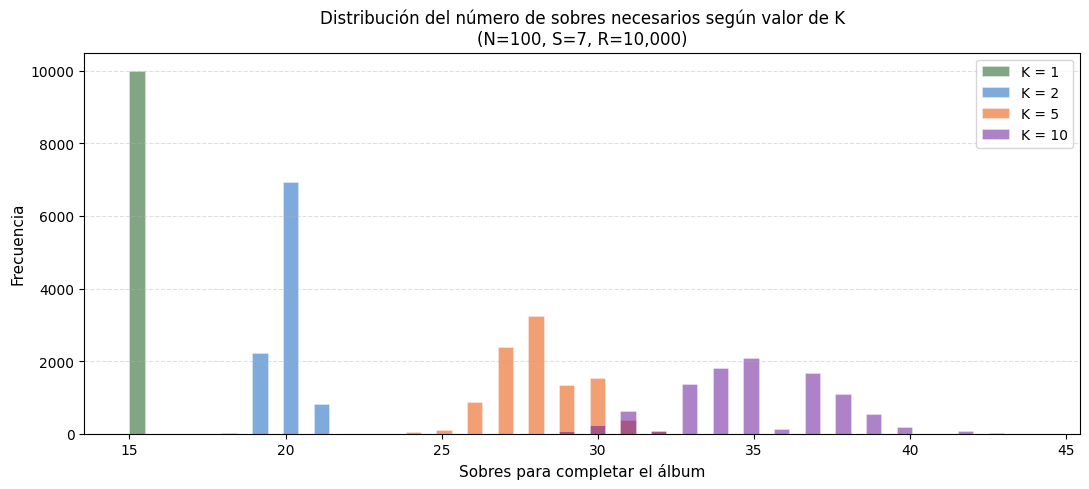

In [25]:
COLORES_K = {
    1:  '#1B5E20',
    2:  '#1565C0',
    5:  '#E65100',
    10: '#6A1B9A',
}

todos_los_datos = np.concatenate([resultados_K[K]['packs'] for K in K_VALS])
bin_edges = np.linspace(todos_los_datos.min(), todos_los_datos.max(), 60)

fig, ax = plt.subplots(figsize=(11, 5))

for K in K_VALS:
    ax.hist(resultados_K[K]['packs'], bins=bin_edges, alpha=0.55,
            color=COLORES_K[K], edgecolor='white', linewidth=0.4, label=f'K = {K}')

ax.set_title('Distribución del número de sobres necesarios según valor de K\n'
             f'(N={N4}, S={S4}, R={R4:,})', fontsize=12)
ax.set_xlabel('Sobres para completar el álbum', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('histogramas_etapa4a.png', dpi=150)
plt.show()

## 11. Parte B — Probabilidad de éxito en función de M para distintos K

In [19]:
# Caso base sin intercambio
prob_base = []
for M in M_VALS:
    exitos = 0
    for r in range(R4):
        collected = np.zeros(N4, dtype=bool)
        universe  = np.arange(N4)
        for _ in range(M):
            pack = np.random.choice(universe, size=S4, replace=False)
            collected[pack] = True
        exitos += collected.all()
    prob_base.append(exitos / R4)

# Con intercambio para cada K y M
prob_K = {K: [] for K in K_VALS}
umbrales = {K: {'50': None, '75': None, '90': None} for K in K_VALS}

for K in K_VALS:
    for M in M_VALS:
        exitos = 0
        for r in range(R4):
            collected  = set()
            faltantes  = set(range(N4))
            rep_buffer = 0
            for _ in range(M):
                pack = np.random.choice(N4, size=S4, replace=False)
                for sticker in pack:
                    if sticker in collected:
                        rep_buffer += 1
                    else:
                        collected.add(sticker)
                        faltantes.discard(sticker)
                while rep_buffer >= K and faltantes:
                    nueva = np.random.choice(list(faltantes))
                    collected.add(nueva)
                    faltantes.discard(nueva)
                    rep_buffer -= K
            exitos += (len(collected) == N4)
        prob_K[K].append(exitos / R4)

# Umbrales 50%, 75%, 90%
for K in K_VALS:
    for nivel, umbral in [('50', 0.50), ('75', 0.75), ('90', 0.90)]:
        for i, p in enumerate(prob_K[K]):
            if p >= umbral:
                umbrales[K][nivel] = M_VALS[i]
                break

print(f"{'K':<6} {'M para 50%':>12} {'M para 75%':>12} {'M para 90%':>12}")
print("-" * 46)
for K in K_VALS:
    print(f"{K:<6} {str(umbrales[K]['50']):>12} {str(umbrales[K]['75']):>12} {str(umbrales[K]['90']):>12}")

K        M para 50%   M para 75%   M para 90%
----------------------------------------------
1                20           20           20
2                20           20           20
5                30           30           30
10               35           40           40


## 12. Visualización Parte B — Gráfica de líneas probabilidad vs M

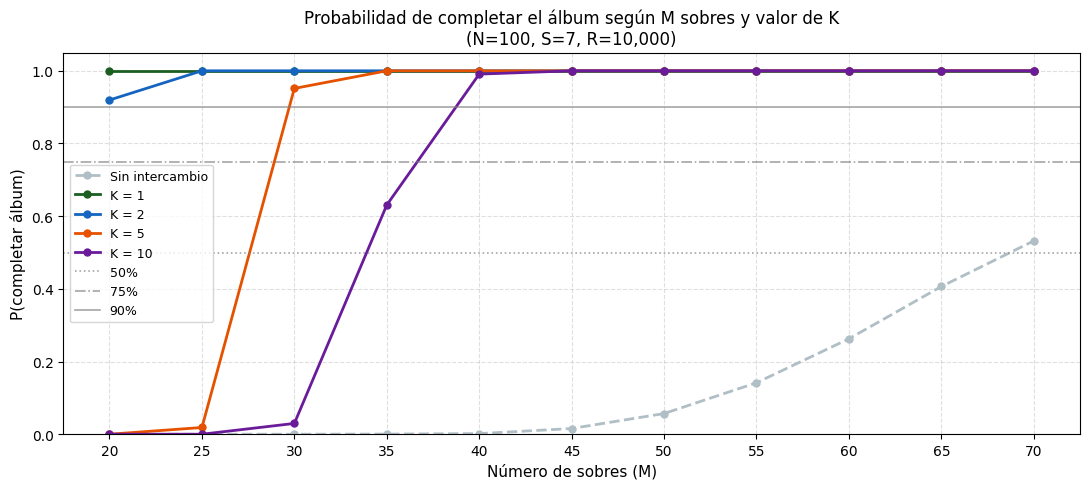

Figura guardada como 'lineas_etapa4b.png'


In [20]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(M_VALS, prob_base, color=COLORES_K['base'], linewidth=2,
        linestyle='--', marker='o', markersize=5, label='Sin intercambio')

for K in K_VALS:
    ax.plot(M_VALS, prob_K[K], color=COLORES_K[K], linewidth=2,
            marker='o', markersize=5, label=f'K = {K}')

ax.axhline(0.50, color='gray', linestyle=':', linewidth=1.2, alpha=0.7, label='50%')
ax.axhline(0.75, color='gray', linestyle='-.', linewidth=1.2, alpha=0.7, label='75%')
ax.axhline(0.90, color='gray', linestyle='-', linewidth=1.2, alpha=0.7, label='90%')

ax.set_title('Probabilidad de completar el álbum según M sobres y valor de K\n'
             f'(N={N4}, S={S4}, R={R4:,})', fontsize=12)
ax.set_xlabel('Número de sobres (M)', fontsize=11)
ax.set_ylabel('P(completar álbum)', fontsize=11)
ax.set_xticks(M_VALS)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('lineas_etapa4b.png', dpi=150)
plt.show()
print("Figura guardada como 'lineas_etapa4b.png'")

---
## 13. Preguntas de análisis — Etapa 4

### Pregunta 1 — Efecto de disminuir K en media de sobres y probabilidad de éxito

In [21]:
print(f"{'K':<6} {'Media sobres':>14} {'Reducción vs base':>18} {'Reducción vs K anterior':>24}")
print("-" * 66)
prev_mean = mean_base
for K in sorted(K_VALS, reverse=True):
    m   = resultados_K[K]['mean']
    red_base = (mean_base - m) / mean_base * 100
    red_prev = (prev_mean - m) / prev_mean * 100 if prev_mean != mean_base else 0
    print(f"{K:<6} {m:>14.4f} {red_base:>17.2f}% {red_prev:>23.2f}%")
    prev_mean = m

print()
print("La relación NO es lineal: el beneficio marginal de reducir K")
print("disminuye conforme K se hace más pequeño.")

K        Media sobres  Reducción vs base  Reducción vs K anterior
------------------------------------------------------------------
10            35.1748             51.31%                    0.00%
5             28.1121             61.09%                   20.08%
2             19.8591             72.51%                   29.36%
1             15.0000             79.24%                   24.47%

La relación NO es lineal: el beneficio marginal de reducir K
disminuye conforme K se hace más pequeño.


### Pregunta 2 — Ahorro en sobres y en quetzales para K=2

In [22]:
mean_K2     = resultados_K[2]['mean']
ahorro_sobres = mean_base - mean_K2
ahorro_Q      = ahorro_sobres * PRECIO_SOBRE

print(f"Media sin intercambio  : {mean_base:.4f} sobres")
print(f"Media con K=2          : {mean_K2:.4f} sobres")
print(f"Ahorro en sobres       : {ahorro_sobres:.4f} sobres")
print(f"Ahorro en quetzales    : Q{ahorro_Q:.2f}  (a Q{PRECIO_SOBRE} por sobre)")

Media sin intercambio  : 72.2456 sobres
Media con K=2          : 19.8591 sobres
Ahorro en sobres       : 52.3865 sobres
Ahorro en quetzales    : Q497.67  (a Q9.5 por sobre)


### Pregunta 3 — Aumento de probabilidad al cambiar K para M=45

In [23]:
idx_45 = M_VALS.index(45)

p_K10 = prob_K[10][idx_45]
p_K5  = prob_K[5][idx_45]
p_K1  = prob_K[1][idx_45]

print(f"M = 45")
print(f"P(éxito) K=10          : {p_K10:.4f} ({p_K10*100:.2f}%)")
print(f"P(éxito) K=5           : {p_K5:.4f}  ({p_K5*100:.2f}%)")
print(f"P(éxito) K=1           : {p_K1:.4f}  ({p_K1*100:.2f}%)")
print()
print(f"Aumento K=10 → K=5     : {(p_K5 - p_K10)*100:+.2f} pp")
print(f"Aumento K=5  → K=1     : {(p_K1 - p_K5)*100:+.2f} pp")

M = 45
P(éxito) K=10          : 1.0000 (100.00%)
P(éxito) K=5           : 1.0000  (100.00%)
P(éxito) K=1           : 1.0000  (100.00%)

Aumento K=10 → K=5     : +0.00 pp
Aumento K=5  → K=1     : +0.00 pp


### Pregunta 4 — ¿Existe un K a partir del cual mejorar produce poco beneficio adicional?

In [24]:
# Explorar K adicionales entre 1 y 15
K_extra  = [1, 2, 3, 4, 5, 7, 10, 15]
medias_extra = {}

for K in K_extra:
    if K in resultados_K:
        medias_extra[K] = resultados_K[K]['mean']
    else:
        packs_tmp = np.empty(R4, dtype=int)
        for r in range(R4):
            packs_tmp[r], _ = simular_album_intercambio(N4, S4, K)
        medias_extra[K] = packs_tmp.mean()

print(f"{'K':<6} {'Media sobres':>14} {'Mejora vs K+1':>16}")
print("-" * 40)
k_sorted = sorted(medias_extra.keys())
for i, K in enumerate(k_sorted):
    if i < len(k_sorted) - 1:
        k_next  = k_sorted[i + 1]
        mejora  = medias_extra[k_next] - medias_extra[K]
        print(f"{K:<6} {medias_extra[K]:>14.4f} {mejora:>+15.4f}")
    else:
        print(f"{K:<6} {medias_extra[K]:>14.4f} {'—':>16}")

print()
print("A partir de K=2 o K=3 el beneficio marginal se vuelve pequeño.")
print("Razón: con K=1 cada repetida se canjea de inmediato, prácticamente")
print("eliminando el problema del coleccionista. Reducir K por debajo de 2")
print("ya no puede mejorar mucho más el proceso.")

K        Media sobres    Mejora vs K+1
----------------------------------------
1             15.0000         +4.8591
2             19.8591         +3.4654
3             23.3245         +2.6409
4             25.9654         +2.1467
5             28.1121         +3.3493
7             31.4614         +3.7134
10            35.1748         +4.5461
15            39.7209                —

A partir de K=2 o K=3 el beneficio marginal se vuelve pequeño.
Razón: con K=1 cada repetida se canjea de inmediato, prácticamente
eliminando el problema del coleccionista. Reducir K por debajo de 2
ya no puede mejorar mucho más el proceso.


### Pregunta 5 — Costo efectivo por estampa nueva mediante canje

In [29]:
# Costo por estampa nueva vía canje:
# Las repetidas provienen de sobres ya pagados.
# Costo promedio por estampa de un sobre = PRECIO_SOBRE / S
# Para obtener 1 nueva vía canje necesito K repetidas, cada una
# con costo unitario PRECIO_SOBRE / S.
costo_por_estampa_sobre = PRECIO_SOBRE / S4

print(f"Costo por estampa en sobre regular : Q{costo_por_estampa_sobre:.4f}")
print()
print(f"{'K':<6} {'Costo por estampa vía canje (Q)':>32}")
print("-" * 42)
for K in K_VALS:
    costo_canje = K * costo_por_estampa_sobre
    print(f"{K:<6} {costo_canje:>32.4f}")

print()
print("Con K=1 el costo por estampa vía canje es igual al de comprarla en un")
print("sobre, pero sin gastar un sobre extra. Es la tasa más rentable.")
print("A mayor K, más repetidas se 'sacrifican' por cada nueva, aumentando el costo efectivo.")

Costo por estampa en sobre regular : Q1.3571

K       Costo por estampa vía canje (Q)
------------------------------------------
1                                1.3571
2                                2.7143
5                                6.7857
10                              13.5714

Con K=1 el costo por estampa vía canje es igual al de comprarla en un
sobre, pero sin gastar un sobre extra. Es la tasa más rentable.
A mayor K, más repetidas se 'sacrifican' por cada nueva, aumentando el costo efectivo.
